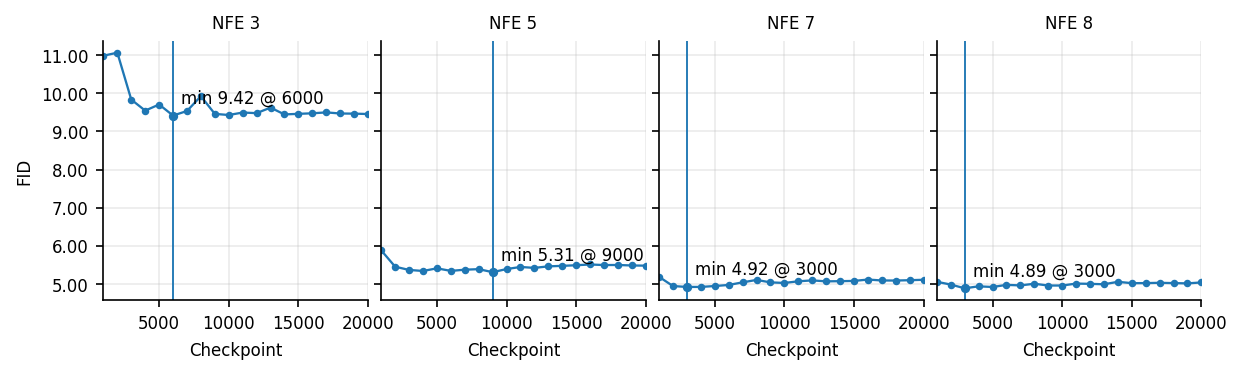

In [2]:
# 1x4 subplots — NFE {3,5,7,8}, super-tight layout
# Coarse ticks, FID 2 decimals, NO save/show, NO (a)(b)(c) labels

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter

mpl.rcParams.update({
    "figure.dpi":150,"font.size":8,"axes.labelsize":8,"axes.titlesize":8,
    "axes.linewidth":0.8,"grid.alpha":0.25,"pdf.fonttype":42,"ps.fonttype":42
})

# ----- data -----
cp = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,11000,12000,13000,14000,15000,16000,17000,18000,19000,20000]
n3  = [10.9871,11.0676,9.836,9.5473,9.7076,9.4178,9.5371,9.9258,9.4617,9.4322,9.4967,9.481,9.626,9.4475,9.4628,9.4767,9.5007,9.4719,9.4678,9.4582]
n5  = [5.8811,5.4528,5.3677,5.3406,5.4099,5.3427,5.3743,5.3884,5.3089,5.3908,5.4459,5.4213,5.4619,5.4746,5.4912,5.5105,5.4962,5.4975,5.4851,5.4801]
n7  = [5.1873,4.9454,4.9215,4.9222,4.9457,4.9737,5.0419,5.1057,5.0416,5.0261,5.0698,5.0936,5.0683,5.0729,5.0796,5.1154,5.0915,5.0896,5.0984,5.1098]
n8  = [5.0566,4.9843,4.886,4.9379,4.9202,4.9759,4.9619,5.0056,4.9587,4.959,5.0096,5.003,4.9916,5.056,5.021,5.0223,5.0301,5.0223,5.0153,5.0396]
series = [(3,n3),(5,n5),(7,n7),(8,n8)]

# shared Y range
ymin = min(min(v) for _,v in series); ymax = max(max(v) for _,v in series)
m = 0.05*(ymax-ymin); ymin, ymax = ymin-m, ymax+m

fig, axs = plt.subplots(1,4, figsize=(8.0,2.4), sharex=True, sharey=True)

for i,(nfe, y) in enumerate(series):
    ax = axs[i]
    ax.plot(cp, y, marker="o", linewidth=1.1, markersize=2.6)
    k = min(range(len(y)), key=y.__getitem__); xmin, yminv = cp[k], y[k]
    ax.axvline(xmin, linewidth=0.9); ax.scatter([xmin],[yminv], s=12, zorder=3)
    ax.annotate(f"min {yminv:.2f} @ {xmin}", (xmin, yminv),
                xytext=(4,6), textcoords="offset points")
    ax.set_title(f"NFE {nfe}")
    ax.set_ylim(ymin, ymax); ax.set_xlim(min(cp), max(cp))
    # coarse ticks
    ax.xaxis.set_major_locator(MultipleLocator(5000))   # 5k
    ax.yaxis.set_major_locator(MultipleLocator(1.0))    # 1.0
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"{v:.2f}"))
    # minimalist styling
    ax.grid(True, which="major", alpha=0.25)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.set_xlabel("Checkpoint")
    if i==0: ax.set_ylabel("FID")
    else:    ax.tick_params(axis="y", labelleft=False)  # 붙여 보이게 좌측만 y라벨

# super-tight spacing
plt.subplots_adjust(left=0.08, right=0.995, top=0.92, bottom=0.20, wspace=0.05, hspace=0.0)
# no save, no show
